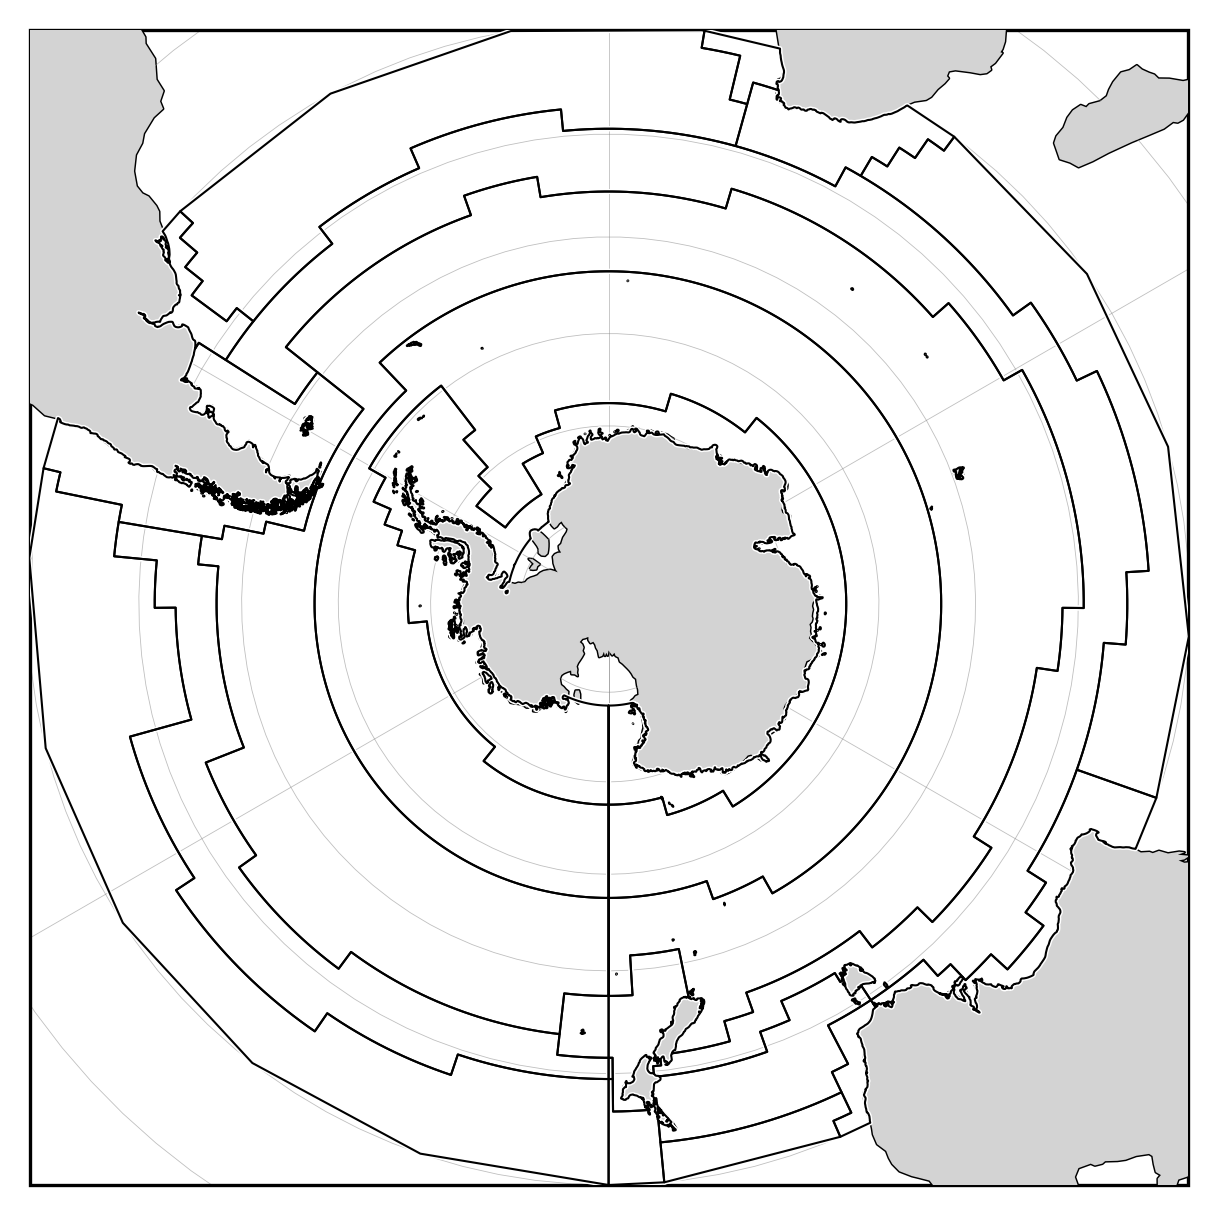

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import box

# ================================
# === LOAD + CLIP LONGHURST ======
# ================================
LONGHURST_PATH = "data/longhurst_v4_2010/Longhurst_world_v4_2010.shp" 

lh = gpd.read_file(LONGHURST_PATH)

# Ensure lon/lat CRS (WGS84)
if lh.crs is None:
    lh = lh.set_crs("EPSG:4326")
else:
    lh = lh.to_crs("EPSG:4326")

# Clip to Southern Ocean domain used in your map
south_box = box(-180, -90, 180, -30)
lh_south = lh[lh.intersects(south_box)].copy()
lh_south["geometry"] = lh_south.intersection(south_box)

# ================================
# === PLOT MAP (YOUR PARAMS) =====
# ================================
fig = plt.figure(figsize=(5, 5), dpi=300)
ax = plt.axes(projection=ccrs.SouthPolarStereo())

ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())

ax.coastlines(resolution="110m", linewidth=0.7)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=12)
ax.gridlines(draw_labels=False, linewidth=0.2, color="gray", alpha=0.5)

lh_south.plot(ax=ax, transform=ccrs.PlateCarree(),
              facecolor="none", edgecolor="white", linewidth=1.2, zorder=18)
lh_south.plot(ax=ax, transform=ccrs.PlateCarree(),
              facecolor="none", edgecolor="black", linewidth=0.5, zorder=19)

# CRITICAL LINE — must be LAST
ax.set_aspect("equal", adjustable="box")

fig.set_size_inches(5, 5, forward=True)
fig.savefig("figs/southern_ocean_longhurst.png", dpi=300)
plt.show()




## Do Longhurst provinces correspond to distinct physical regimes in the Southern Ocean?

MLD is a consequence of Δσθ, not the driver. So using Δσθ as a first step toward constraining the physics inside the provinces.

### Velocity forcing: GLORYS monthly climatology

This simulation uses the **Copernicus Marine GLORYS monthly climatology**
(`cmems_mod_glo_phy_my_0.083deg-climatology_P1M-m`).

- Each monthly field represents the **mean over 1993–2016**
- The climatology is computed **separately for each calendar month** (Jan–Dec)
- The time axis (year 2004) is a **reference year only** and does not correspond to real conditions
- The velocity field therefore represents a **repeating seasonal cycle**, with no interannual variability

**Variables used**
- `uo`, `vo` — zonal and meridional velocity  
- `thetao` — potential temperature  
- `so` — salinity  

**Resolution**
- Horizontal: **1/12° (~8 km)**
- Vertical: **50 depth levels**

This setup represents the **mean seasonal circulation** and is suitable for
studying typical drift pathways of floats deployed during austral summer (e.g. OISO campaigns).


In [1]:
import copernicusmarine

copernicusmarine.subset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg-climatology_P1M-m",
    variables=["uo", "vo", "thetao", "so"],
    minimum_longitude=-180,
    maximum_longitude=180,
    minimum_latitude=-75,
    maximum_latitude=-20,
    output_directory="/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/OTHER/data",
)


/home/ldelaigue/.conda/envs/soca/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO - 2026-01-26T14:29:11Z - Selected dataset version: "202311"
INFO - 2026-01-26T14:29:11Z - Selected dataset part: "default"
INFO - 2026-01-26T14:29:12Z - Starting download. Please wait...
100%|██████████| 796/796 [02:37<00:00,  5.07it/s] 
INFO - 2026-01-26T14:31:54Z - Successfully downloaded to /remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/OTHER/data/cmems_mod_glo_phy_my_0.083deg-climatology_P1M-m_uo-vo-thetao-so_180.00W-179.92E_75.00S-20.00S_0.49-5727.92m_2004-01-01-2004-12-01.nc


ResponseSubset(file_path=PosixPath('/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/OTHER/data/cmems_mod_glo_phy_my_0.083deg-climatology_P1M-m_uo-vo-thetao-so_180.00W-179.92E_75.00S-20.00S_0.49-5727.92m_2004-01-01-2004-12-01.nc'), output_directory=PosixPath('/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/OTHER/data'), filename='cmems_mod_glo_phy_my_0.083deg-climatology_P1M-m_uo-vo-thetao-so_180.00W-179.92E_75.00S-20.00S_0.49-5727.92m_2004-01-01-2004-12-01.nc', file_size=13078.730557251909, data_transfer_size=127365.96421374046, variables=['uo', 'vo', 'thetao', 'so'], coordinates_extent=[GeographicalExtent(minimum=-180.0, maximum=179.9166717529297, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=-75.0, maximum=-20.0, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2004-01-01T00:00:00+00:00', maximum='2004-12-01T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=0.49402499198913574, maximum=5727.916

In [4]:
import numpy as np
import xarray as xr
import gsw

# =========================================
# 0) LOAD + KEEP ONLY UPPER 250 m
# =========================================
print("Loading dataset...")
ds = xr.load_dataset(
    "data/cmems_mod_glo_phy_my_0.083deg-climatology_P1M-m_uo-vo-thetao-so_180.00W-179.92E_75.00S-20.00S_0.49-5727.92m_2004-01-01-2004-12-01.nc"
)

print("Keeping depths <= 250 m and only [so, thetao]...")
ds = ds.sel(depth=ds.depth <= 250)[["so", "thetao"]]

print("Depth levels kept:", ds.sizes["depth"])
print("Max depth kept (m):", float(ds.depth.max()))

# =========================================
# 1) STATIC GRIDS (lon/lat) + PRESSURE FIELDS
# =========================================
print("Building lon/lat grids...")
lon2d, lat2d = xr.broadcast(ds["longitude"], ds["latitude"])

print("Computing pressure fields (surface ~5 m, and 200 m)...")
p_surf = xr.apply_ufunc(
    gsw.p_from_z,
    -5.0, lat2d,
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
).rename("p_surf")

p_200 = xr.apply_ufunc(
    gsw.p_from_z,
    -200.0, lat2d,
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
).rename("p_200")

# =========================================
# 2) SURFACE (0–10 m mean) + 200 m (interp)
# =========================================
print("Computing surface (0–10 m mean) and 200 m (interpolated) fields...")

so_surf = ds["so"].sel(depth=slice(0, 10)).mean("depth")
pt_surf = ds["thetao"].sel(depth=slice(0, 10)).mean("depth")

so_200 = ds["so"].interp(depth=200)
pt_200 = ds["thetao"].interp(depth=200)

# =========================================
# 3) TEOS-10: SP -> SA, pt -> CT, then sigma0
# =========================================
print("Computing sigma0 at surface...")

SA_surf = xr.apply_ufunc(
    gsw.SA_from_SP,
    so_surf, p_surf, lon2d, lat2d,
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
).rename("SA_surf")

CT_surf = xr.apply_ufunc(
    gsw.CT_from_pt,
    SA_surf, pt_surf,
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
).rename("CT_surf")

sigma0_surf = xr.apply_ufunc(
    gsw.sigma0,
    SA_surf, CT_surf,
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
).rename("sigma0_surf")

print("Computing sigma0 at 200 m...")

SA_200 = xr.apply_ufunc(
    gsw.SA_from_SP,
    so_200, p_200, lon2d, lat2d,
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
).rename("SA_200")

CT_200 = xr.apply_ufunc(
    gsw.CT_from_pt,
    SA_200, pt_200,
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
).rename("CT_200")

sigma0_200 = xr.apply_ufunc(
    gsw.sigma0,
    SA_200, CT_200,
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
).rename("sigma0_200")

# =========================================
# 4) Δσθ = σ0(200 m) − σ0(surface)
# =========================================
print("Computing Δσθ = σ0(200 m) − σ0(surface 0–10 m mean)...")

delta_sigma = (sigma0_200 - sigma0_surf).rename("delta_sigma_theta_200m")
delta_sigma.attrs["long_name"] = "Δσθ = σ0(200 m) − σ0(surface 0–10 m mean)"
delta_sigma.attrs["units"] = "kg m-3"

# =========================================
# 5) COMPUTE + SAVE
# =========================================
print("Forcing computation...")
delta_sigma = delta_sigma.compute()
print("Done.")

print("Saving to NetCDF...")
delta_sigma.to_netcdf("data/delta_sigma_theta_200m_monthly.nc")
print("Saved: data/delta_sigma_theta_200m_monthly.nc")

print(delta_sigma)


Loading dataset...
Keeping depths <= 250 m and only [so, thetao]...
Depth levels kept: 27
Max depth kept (m): 222.47520446777344
Building lon/lat grids...
Computing pressure fields (surface ~5 m, and 200 m)...
Computing surface (0–10 m mean) and 200 m (interpolated) fields...
Computing sigma0 at surface...
Computing sigma0 at 200 m...
Computing Δσθ = σ0(200 m) − σ0(surface 0–10 m mean)...
Forcing computation...
Done.
Saving to NetCDF...
Saved: data/delta_sigma_theta_200m_monthly.nc
<xarray.DataArray 'delta_sigma_theta_200m' (time: 12, latitude: 661,
                                            longitude: 4320)> Size: 274MB
array([[[0.64264423, 0.64676414, 0.65188882, ..., 0.63030211,
         0.63464117, 0.63819911],
        [0.63609765, 0.64001313, 0.64521243, ..., 0.62443819,
         0.6269383 , 0.63180222],
        [0.63175618, 0.63573996, 0.64015597, ..., 0.62047565,
         0.62444121, 0.62801758],
        ...,
        [2.53270695, 2.53519269, 2.53725392, ..., 2.54400789,
       